In [39]:
import sys

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

# Load usefull functions
from propa.rtf.ideal_waveguide import *

# Formulation générale 

Pour un signal source large bande $S(f)$, le champ de pression reçu à la profondeur $z$ après propagation sur une distance radiale $r$ est donnée par :

$
    p(f, r, z) \simeq S(f) \times \frac{e^{i\pi/4}}{\rho(z_s) \sqrt{8 \pi}}  \sum_{n=1}^{\infty} \Psi_n(z_s) \Psi_n(z) \frac{e^{-ik_{n} r}}{\sqrt{k_{n} r}}
$

Dans la suite on note,

$
    Q_s =  \frac{e^{i\pi/4}}{\rho(z_s) \sqrt{8 \pi}}
$

Pour un récepteur $m$ de position $\mathbf{x_m}(r_m, z_m)$ et une source j de position $\mathbf{x_{s_j}}(r_{s_j}, z_{s_j})$, la fonction de transfert acoustique associée est donnée par :

$
    H_{mj} = Q_j \sum_{n=1}^{\infty} \Psi_n(z_{s_j}) \Psi_n(z_m) \frac{e^{-ik_{n} r_{mj}}}{\sqrt{k_{n} r_{mj}}}
$


## Cas d'étude : le guide d'onde idéal 
 
L'objectif étant ici de vérifier numériquement les calculs analytiques on considère le guide d'onde idéal (fond et surface parfaitement réfléchissant : p(z=0) = 0 et p(z = D) = 0)


Les fonctions modales du guide d'onde idéal sont données par,

$    
\Psi_m(z) = \sqrt{\frac{2 \rho}{D}} \sin(k_{zm} z)
$

Les fonctions $\Psi_m$ sont les fonctions propres associées aux valeurs propres $k_{rm}$ vérifiant :

$    
k_{rm} = \sqrt{ k^2 - k_{zm}^2}                                                                   
    = \sqrt{ \frac{\omega^2}{c_0^2} - \left ( \frac{m\pi}{D}  \right )^2 }, \quad m \in \mathbb{N}
$

## Angle hermitien 

On s'intéresse à la distance entre les vecteurs de RTF $\mathbf{\Pi_1}$ et $\mathbf{\Pi_2}$ définie par l'angle Hermitien associé,

$    
\theta_{12} = \arccos \left ( \frac{ \lvert \mathbf{\Pi_1}^H \mathbf{\Pi_2} \rvert }{\lVert \mathbf{\Pi_1}\rVert \lVert \mathbf{\Pi_2} \rVert} \right )
$

# Cas M = 2

Considérons dans un premier temps le cas simplifié d'une antenne à 2 capteurs.

## Cas N = 1
On considère dans un premier temps le cas très simplifié d'un unique mode propagatif. 

On a :

$ \theta_{12} = \arccos \left ( \frac{a'}{b'} \right) $ 

et, 

$
a' = \left \lvert \frac{Q_1  \overline{Q_2}}{k_1} \Psi_1(z_{s_1}) \overline{\Psi_1(z_{s_2})} \left ( \lvert \Psi_1(z_1) \rvert^2 \frac{e^{-ik_{1} \left ( r_{11} - r_{12} \right )}}{\sqrt{r_{11} r_{12} }} + \lvert \Psi_1(z_2) \rvert^2 \frac{e^{-ik_{1} \left ( r_{21} - r_{22} \right )}}{\sqrt{r_{21} r_{22} }}  \right ) \right \rvert
$

### ETUDE NUMERIQUE

#### Calcul de la fonction modale

In [40]:
# Parameters
D = 1000 # Depth of the waveguide 
z1 = 950 # Depth of receiver 1
r1 = 0 # Range of receiver 1
z2 = 950 # Depth of receiver 2
r2 = 100 # Range of receiver 2
zs1 = 100 # Depth of source 1
zs2 = 100 # Depth of source 2
rs1 = 1e5 # Range of source 1
rs2 = 1e5 + 100 # Range of source 2

f = 25 # Frequency in Hz
f = np.arange(5, 50, 0.01)

# Derive distances
r11 = rs1 - r1
r12 = rs2 - r1
r21 = rs1 - r2
r22 = rs2 - r2

n = 3
f, h11 = h(f=f, z_src=zs1, z=z1, r=r11, depth=D, bottom_bc="pressure_release", n=n)
f, h12 = h(f=f, z_src=zs2, z=z1, r=r12, depth=D, bottom_bc="pressure_release", n=n)
f, h21 = h(f=f, z_src=zs1, z=z2, r=r21, depth=D, bottom_bc="pressure_release", n=n)
f, h22 = h(f=f, z_src=zs2, z=z2, r=r22, depth=D, bottom_bc="pressure_release", n=n)

Text(0.5, 0, 'Frequency (Hz)')

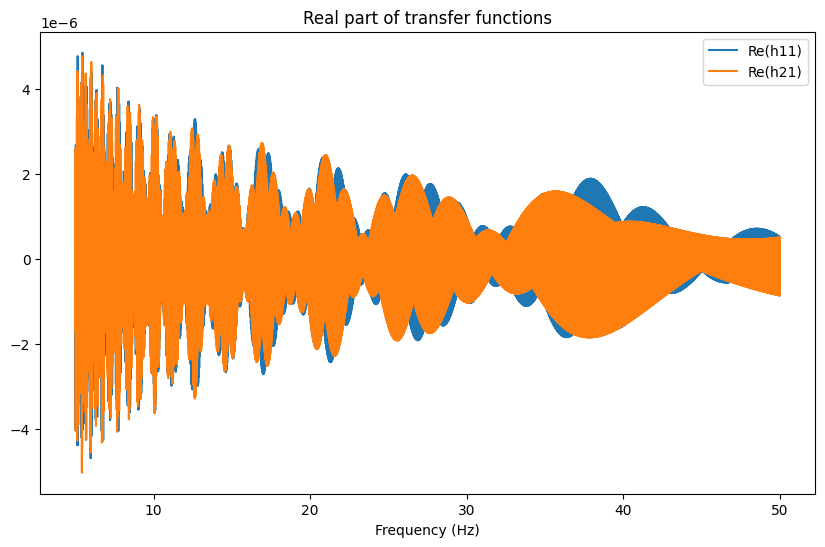

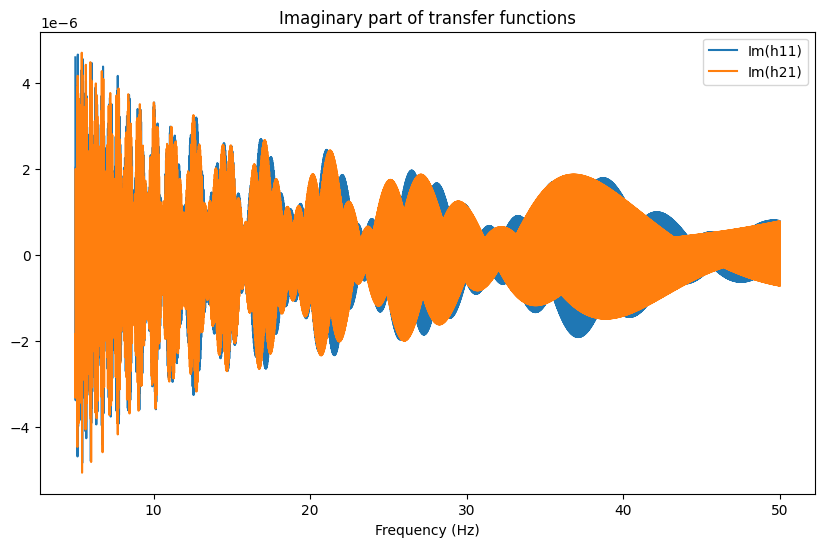

In [41]:
# Plot transfer functions

plt.figure(figsize=(10, 6))
plt.plot(f, np.real(h11), label="Re(h11)")
# plt.plot(f, np.real(h12), label="Re(h12)")
plt.plot(f, np.real(h21), label="Re(h21)")
# plt.plot(f, np.real(h22), label="Re(h22)")
plt.legend(loc="upper right")
plt.title("Real part of transfer functions")
plt.xlabel("Frequency (Hz)")

plt.figure(figsize=(10, 6))
plt.plot(f, np.imag(h11), label="Im(h11)")
# plt.plot(f, np.imag(h12), label="Im(h12)")
plt.plot(f, np.imag(h21), label="Im(h21)")
# plt.plot(f, np.imag(h22), label="Im(h22)")
plt.legend(loc="upper right")
plt.title("Imaginary part of transfer functions")
plt.xlabel("Frequency (Hz)")
# plt.show()

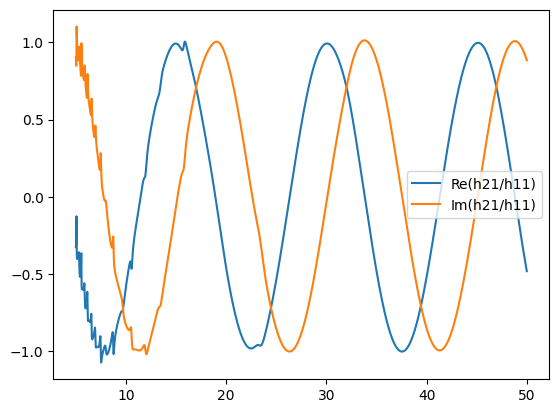

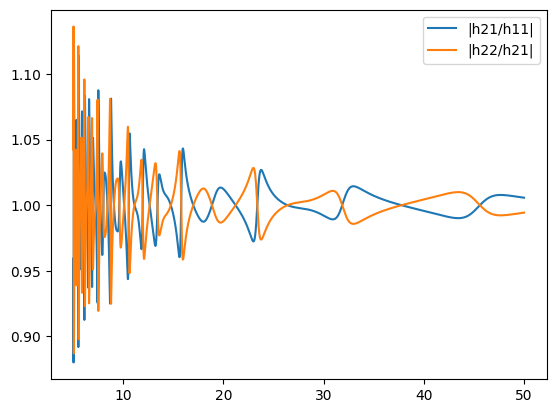

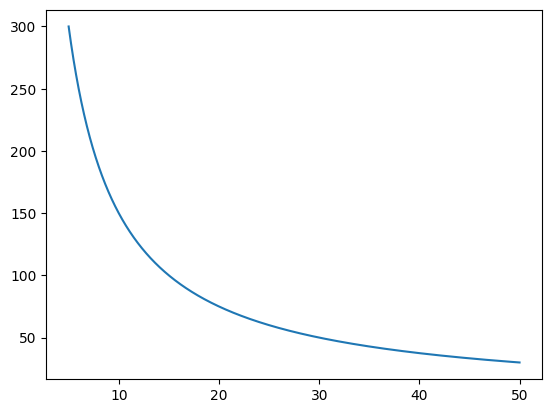

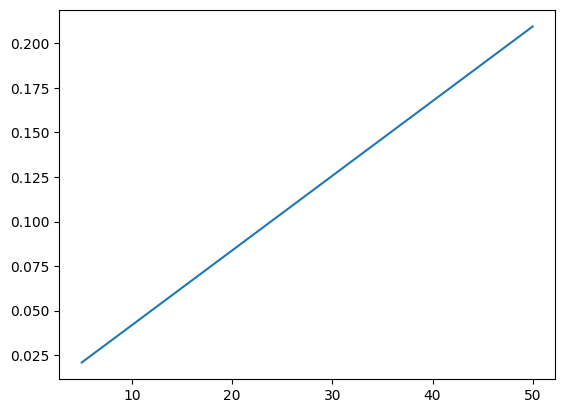

In [42]:
plt.figure()
plt.plot(f, np.real(h21 / h11), label="Re(h21/h11)")
# plt.plot(f, np.real(h22 / h21), label="Re(h22/h21)")
plt.plot(f, np.imag(h21 / h11), label="Im(h21/h11)")
# plt.plot(f, np.imag(h22 / h21), label="Im(h22/h21)")
plt.legend()

plt.figure()
plt.plot(f, np.abs(h21 / h11), label="|h21/h11|")
plt.plot(f, np.abs(h22 / h21), label="|h22/h21|")
plt.legend()

# stft d'une composante du vecteur de RTF
# import scipy.signal as sp 
# f_win = 1
# fs = 1/(f[1]-f[0])
# nperseg = int(f_win * fs)
# nov = int(0.9 * nperseg)
# ff, tt, pi_21_xx = sp.stft(x=np.abs(h21 / h11), fs=fs, nperseg=nperseg)

# plt.figure()
# plt.pcolormesh(tt, ff, np.abs(pi_21_xx))
# plt.ylim([0, 5])

plt.figure()
plt.plot(f, c0 / f)

plt.figure()
plt.plot(f, 2*np.pi / c0 * f)

In [43]:
theta

NameError: name 'theta' is not defined

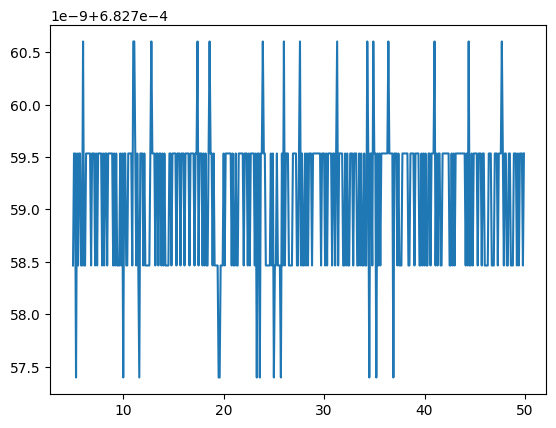

In [ ]:
plt.figure()
plt.plot(f, theta, label=r"$\theta$")

In [ ]:
# Build it manually for N = 1

Q = np.exp(1j * np.pi / 4)  / (rho_0 * np.sqrt(8 * np.pi))
k1 = kr(m=1, f=f, depth=D, bottom_bc="pressure_release")

def psi_1(z):
    return psi(m=1, z=z, depth=D, bottom_bc="pressure_release")




In [ ]:
a = np.abs(
    np.abs(psi_1(z1)) ** 2 / (np.sqrt(r11 * r12))
    + np.abs(psi_1(z2)) ** 2 / (np.sqrt(r21 * r22))
)

b1 = np.abs(psi_1(z1)) ** 2 / (r11 * r12) + np.abs(psi_1(z2)) ** 2 / (r21 * r22)
b2 = np.abs(psi_1(z1) * psi_1(z2)) ** 2 / (r11 * r22) + np.abs(
    psi_1(z1) * psi_1(z2)
) ** 2 / (r21 * r21)
b = np.sqrt(b1 + b2)

c = np.arccos(a / b)

In [ ]:
c * 180/np.pi

77.37644089434349